# Follow chemicals through thyroid-related pathways

The following notebook showcases how to use the `rdfsolve.client_api` to explore
the AOPWiki RDF SPARQL endpoint and answer three research questions:

- Which chemicals appear in thyroid-related pathways?
- What names and identifiers do they have?
- Which other pathways and key events are linked to them?

Run cells in order.

## Open AOPWiki

`explore()` reads the available classes and fields, then gives us a typed Python API to query them.

In [1]:
from rdfsolve.client_api import explore

data = explore(
    "https://aopwiki.rdf.bigcat-bioinformatics.org/sparql",
    graph="http://aopwiki.org/",
)

## The classes we will use

Each box shows a class label and its identifier. Arrows are links recorded in the data.

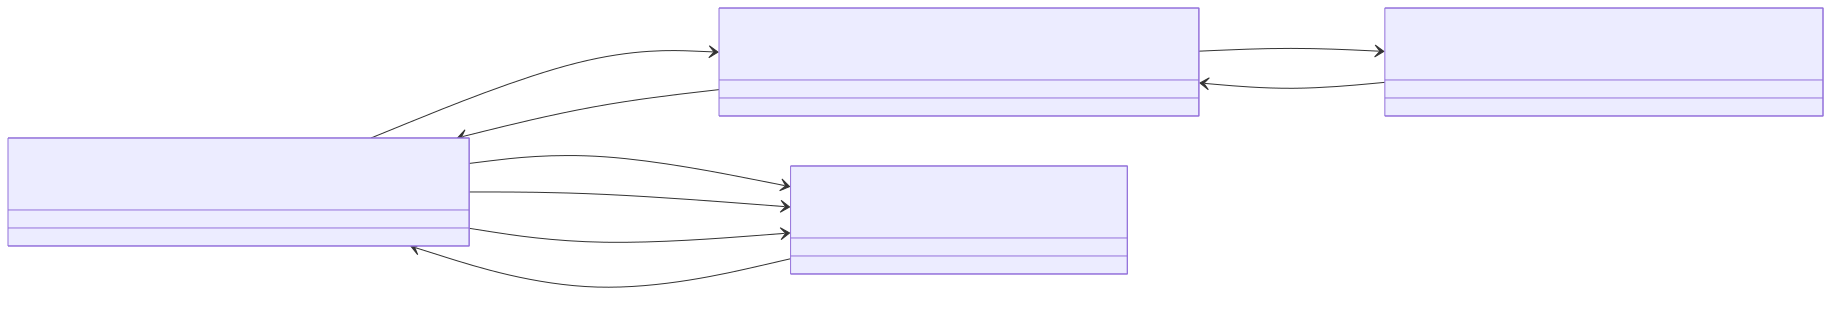

In [2]:
from IPython.display import Markdown

Markdown(data.diagram("Adverse outcome pathway", "Stressor", "Chemical entity", "Key event"))

## Text search

`find()` searches names and identifiers. `types()` shows the classes of the matches. What mentions “thyroid”?

In [3]:
matches = data.find("thyroid")
matches.types()

,Class,Matches,Example
0,Adverse Outcome Pathway,18,Inhibition of thyroid peroxidase leading to fo...
1,Cell-term,1,thyroid follicular cell
2,Key Event,11,"Increased, Thyroid-stimulating hormone (TSH)"
3,Organ-term,2,thyroid gland
4,Go0008150,2,thyroid hormone generation
5,physical object quality,4,thyroid hormone


## Look at the pathways

`of_type()` keeps one class from our matches. Here we keep adverse outcome pathways.

In [4]:
pathways = matches.of_type("Adverse Outcome Pathway")
pathways

Name,Class
Inhibition of thyroid peroxidase leading to follicular cell adenomas and carcinomas (in rat and mouse),Adverse Outcome Pathway
Kidney dysfunction by decreased thyroid hormone,Adverse Outcome Pathway
Interference with thyroid serum binding protein transthyretin and subsequent adverse human neurodevelopmental toxicity,Adverse Outcome Pathway
Enhanced hepatic clearance of thyroid hormones leading to thyroid follicular cell adenomas and carcinomas in the rat and mouse,Adverse Outcome Pathway
Inhibition of thyroid peroxidase leading to impaired fertility in fish,Adverse Outcome Pathway
Thyroid Receptor Antagonism and Subsequent Adverse Neurodevelopmental Outcomes in Mammals,Adverse Outcome Pathway
Competitive binding to thyroid hormone carrier protein transthyretin (TTR) leading to altered amphibian metamorphosis,Adverse Outcome Pathway
Competitive binding to thyroid hormone carrier protein thyroid binding globulin (TBG) leading to altered amphibian metamorphosis,Adverse Outcome Pathway
AOP for thyroid disorder caused by triphenyl phosphate via TRβ activation,Adverse Outcome Pathway
Thyroid peroxidase (TPO) inhibition leads to periventricular heterotopia formation in the developing rat brain,Adverse Outcome Pathway


## What links to an adverse outcome pathway?

`paths()` lists the links we can follow and the class at each end.

In [5]:
pathways.paths()

,From,Link,To
0,Adverse Outcome Pathway,has key event,Key Event
1,Adverse Outcome Pathway,has molecular initiating event,Key Event
2,Adverse Outcome Pathway,cellular organisms,cellular organisms
3,Adverse Outcome Pathway,see also,Adverse Outcome Pathway
4,Adverse Outcome Pathway,identifier,Adverse Outcome Pathway
5,Adverse Outcome Pathway,has adverse outcome,Key Event
6,Adverse Outcome Pathway,has key event relationship,Key Event Relationship
7,Adverse Outcome Pathway,page,Adverse Outcome Pathway
8,Adverse Outcome Pathway,Stressor,Stressor


`paths_between()` lists routes between two classes. Here we allow up to two links. Arrows show each link's direction.

In [6]:
data.paths_between("Adverse outcome pathway", "Chemical entity", max_hops=2)

,Path,Step,From,Link,Direction,To
0,1,1,Adverse Outcome Pathway,Stressor,→,Stressor
1,1,2,Stressor,has chemical entity,→,chemical entity
2,2,1,Adverse Outcome Pathway,Stressor,→,Stressor
3,2,2,Stressor,is part of,←,chemical entity
4,3,1,Adverse Outcome Pathway,is part of,←,Stressor
5,3,2,Stressor,has chemical entity,→,chemical entity
6,4,1,Adverse Outcome Pathway,is part of,←,Stressor
7,4,2,Stressor,is part of,←,chemical entity


## Follow the stressor annotations

`related()` follows links to records of the class we choose.

In [7]:
stressors = pathways.related("Stressor")
stressors

Name,Class
Phenobarbital,Stressor
Polychlorinated biphenyl,Stressor
Halogenated phenols,Stressor
thiazopyr,Stressor
Pyrethrins and Pyrethroids,Stressor
"2,3,7,8-tetrachlorodibenzo-p-dioxin (TCDD)",Stressor
Ethylene thiourea,Stressor
Polychlorinated dibenzodioxins,Stressor
Polybrominated diphenyl ethers,Stressor
Isoflavones,Stressor


## Get the chemicals and their identifiers

`via="Stressor"` takes us through stressors to chemicals. `show()` displays the fields we ask for, alongside each record’s name and class.

In [8]:
chemicals = pathways.related(kind="Chemical entity", via="Stressor")
chemicals.show("identifier")

,Name,Class,Identifier
0,Triphenyl phosphate,chemical entity,https://identifiers.org/cas/115-86-6
1,Thiazopyr,chemical entity,https://identifiers.org/cas/117718-60-2
2,"2,2',4,4'-Tetrahydroxybenzophenone",chemical entity,https://identifiers.org/cas/131-55-5
3,Clonixin,chemical entity,https://identifiers.org/cas/17737-65-4
4,Phenobarbital,chemical entity,https://identifiers.org/cas/50-06-6
5,6-Propyl-2-thiouracil,chemical entity,https://identifiers.org/cas/51-52-5
6,Triclopyr,chemical entity,https://identifiers.org/cas/55335-06-3
7,Methimazole,chemical entity,https://identifiers.org/cas/60-56-0
8,Meclofenamic acid,chemical entity,https://identifiers.org/cas/644-62-2
9,"3,3',5,5'-Tetrabromobisphenol A",chemical entity,https://identifiers.org/cas/79-94-7


## Look up a name from the list

`value="Phenobarbital"` looks for that name among connected records. `show()` lets us read their other identifiers.

In [9]:
phenobarbital = pathways.related(value="Phenobarbital", via="Stressor").of_type("Chemical entity")
phenobarbital.show("exactmatch")

,Name,Class,Exactmatch
0,Phenobarbital,chemical entity,https://identifiers.org/chebi/8069 | https://i...


Change the name to look for another chemical. Press Tab after `phenobarbital.fields.` to see its available fields.

## How is this chemical connected?

First, list the pathways linked to Phenobarbital.

In [10]:
phenobarbital_pathways = phenobarbital.related("Stressor").related("Adverse outcome pathway")
phenobarbital_pathways

Name,Class
Constitutive androstane receptor activation leading to hepatocellular adenomas and carcinomas in the mouse and the rat,Adverse Outcome Pathway
Enhanced hepatic clearance of thyroid hormones leading to thyroid follicular cell adenomas and carcinomas in the rat and mouse,Adverse Outcome Pathway


`connections()` shows the actual records and links between two choices. `[0]` picks the first record from each list. We allow up to two links, without revisiting a record.

In [11]:
data.connections(phenobarbital[0], phenobarbital_pathways[0], max_hops=2)

,Path,Step,From,From class,Link,Direction,To,To class
0,1,1,https://identifiers.org/cas/50-06-6,chemical entity | CAS registry number,is part of,→,https://identifiers.org/aop.stressor/133,Stressor
1,1,2,https://identifiers.org/aop.stressor/133,Stressor,is part of,→,https://identifiers.org/aop/107,Adverse Outcome Pathway
2,2,1,https://identifiers.org/cas/50-06-6,chemical entity | CAS registry number,is part of,→,https://identifiers.org/aop.stressor/133,Stressor
3,2,2,https://identifiers.org/aop.stressor/133,Stressor,Stressor,←,https://identifiers.org/aop/107,Adverse Outcome Pathway
4,3,1,https://identifiers.org/cas/50-06-6,chemical entity | CAS registry number,has chemical entity,←,https://identifiers.org/aop.stressor/133,Stressor
5,3,2,https://identifiers.org/aop.stressor/133,Stressor,is part of,→,https://identifiers.org/aop/107,Adverse Outcome Pathway
6,4,1,https://identifiers.org/cas/50-06-6,chemical entity | CAS registry number,has chemical entity,←,https://identifiers.org/aop.stressor/133,Stressor
7,4,2,https://identifiers.org/aop.stressor/133,Stressor,Stressor,←,https://identifiers.org/aop/107,Adverse Outcome Pathway


## Follow these chemicals to other pathways

Find their stressor annotations, then the pathways connected to those annotations. Leave out the pathways we already listed.

In [12]:
annotations = chemicals.related("Stressor")
other_pathways = annotations.related("Adverse outcome pathway").without(pathways)
other_pathways

Name,Class
Constitutive androstane receptor activation leading to hepatocellular adenomas and carcinomas in the mouse and the rat,Adverse Outcome Pathway
Thyroperoxidase inhibition leading to increased mortality via reduced anterior swim bladder inflation,Adverse Outcome Pathway
Thyroperoxidase inhibition leading to altered amphibian metamorphosis,Adverse Outcome Pathway
Thyroperoxidase inhibition leading to altered visual function via altered retinal layer structure,Adverse Outcome Pathway
G protein-coupled estrogen receptor 1 (GPER) signal pathway in the lipid metabolism disrupting effects,Adverse Outcome Pathway
Inhibition of Thyroperoxidase and Subsequent Adverse Neurodevelopmental Outcomes in Mammals,Adverse Outcome Pathway
SULT1E1 inhibition leading to uterine adenocarcinoma via increased estrogen availability at target organ level,Adverse Outcome Pathway
"17β-Hydroxysteroid dehydrogenase 2, inhibition leading to activation, estrogen receptor alpha",Adverse Outcome Pathway


## See the key events in those pathways

In [13]:
events = other_pathways.related("Key event", via="has key event")
events

Name,Class
"Decreased, Triiodothyronine (T3)",Key Event
"Reduced, Swimming performance",Key Event
"Reduced, Anterior swim bladder inflation",Key Event
"Activation, estrogen receptor alpha",Key Event
"Altered, Amphibian metamorphosis",Key Event
"Altered gene expression specific to CAR activation, Hepatocytes",Key Event
"Up Regulation, SREBF2",Key Event
"Activation, AKT",Key Event
"Activation, mTORC1",Key Event
"Activation, PI3K",Key Event


## Keep the results

Save the chemical table and the record of how we found it.

In [14]:
chemicals.show("identifier").to_csv("thyroid-chemicals.csv", index=False)
data.save_session("thyroid-session.json")
data.close()

Next: [keep a small dataset](02_subset.ipynb) or [turn the chemical table into RDF](03_to_RDF_schema.ipynb).

## What ran

Open a named query to see what it asked and what came back. These results are also in `thyroid-session.json`.

In [15]:
data.query_log()

class
http://edamontology.org/data_2298
http://edamontology.org/data_1025
http://edamontology.org/data_1027
http://edamontology.org/data_1033
http://edamontology.org/data_2291
http://www.w3.org/ns/prov#Activity
http://www.w3.org/ns/prov#Entity
http://aopkb.org/aop_ontology#CellTypeContext
http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C54571
http://semanticscience.org/resource/CHEMINF_000412
